In [14]:
import pandas as pd
import numpy
import requests
import json
import matplotlib.pyplot as plt
import os


In [2]:
wka = pd.read_excel("Zeitreihen_WKA_2025_2026.xlsx")
weather = pd.read_excel("Zeitreihen_Wetterprognosen_2025_2026.xlsx")

In [3]:
wka.head(10)

,Größe,Unnamed: 1,kW el,kW el.1
0,Richtung,NaN,Einsp,Einsp
1,Zeitraster Min,NaN,15,15
2,Zeitverschiebung UTC,NaN,UTC+1,UTC+1
3,Lokale Zeit,NaN,Nein,Nein
4,Datum_von,Datum_bis,Wert,Wert
5,01.01.2025 00:00:00,01.01.2025 00:15:00,812,851.4
6,01.01.2025 00:15:00,01.01.2025 00:30:00,810,851.8
7,01.01.2025 00:30:00,01.01.2025 00:45:00,808,849.4
8,01.01.2025 00:45:00,01.01.2025 01:00:00,814,844.6
9,01.01.2025 01:00:00,01.01.2025 01:15:00,810,845


In [4]:

url = "https://kshww2.thueringen.de/FROST-Server/v1.1/Things"

response = requests.get(url, timeout=30)
data = response.json()

result = {
    thing["name"]: {
        "description": thing.get("description"),
        "properties": thing.get("properties", {})
    }
    for thing in data["value"]
}


In [5]:
result

{'4834900280': {'description': 'groundwater station (auto-importer)',
  'properties': {'creation_date': '2024-08-13T17:01:25.803000',
   'station_id': '4834900280',
   'type': 'AUTO_IMPORT_SENF'}},
 'Grundwasserstation@5031210655': {'description': 'groundwater station (auto-importer)',
  'properties': {'creation_date': '2024-08-13T17:02:04.725852',
   'station_id': '5031210655',
   'type': 'AUTO_IMPORT_SENF'}},
 'Grundwasserstation@5032210675': {'description': '',
  'properties': {'creation_date': '2024-11-19T13:21:27.821157',
   'station_id': '5032210675',
   'type': 'AUTO_IMPORT_SENF'}},
 'Bodenfeuchte_Messstation@121588': {'description': '',
  'properties': {'creation_date': '2024-11-19T13:48:31.251772',
   'station_id': '121588',
   'type': 'AUTO_IMPORT_SENF'}},
 'Bodenfeuchte_Messstation@121589': {'description': '',
  'properties': {'creation_date': '2024-11-19T16:27:15.585112',
   'station_id': '121589',
   'type': 'AUTO_IMPORT_SENF'}},
 'Bodenfeuchte_Messstation@121590': {'descr

In [6]:
locations = list(result.keys())

In [ ]:
#fetching the data from the water locations
from fetch_data import fetch_data_good

# default Q becase m³ / s is more useful than cm
default_param = "Q"
day_data = "1D"
min_data = "15min"
start_date = "2010-01-01"
end_date = "2026-01-01"

In [12]:
missing_stations = 0

for station in locations:
    try:
        fetch_data_good(station, default_param, day_data, start_date, end_date, "water_data")
    except:
        missing_stations += 1

Station=4834900280  Parameter=Q  Freq=1D  2010-01-01T00:00:00Z → 2026-01-01T00:00:00Z

Error fetching No datastream for parameter='Q', freq='1D' on Thing 113. Run explore_api.py → list_datastreams(113) to see what is available.
Station=Grundwasserstation@5031210655  Parameter=Q  Freq=1D  2010-01-01T00:00:00Z → 2026-01-01T00:00:00Z

Error fetching No datastream for parameter='Q', freq='1D' on Thing 124. Run explore_api.py → list_datastreams(124) to see what is available.
Station=Grundwasserstation@5032210675  Parameter=Q  Freq=1D  2010-01-01T00:00:00Z → 2026-01-01T00:00:00Z

Error fetching No datastream for parameter='Q', freq='1D' on Thing 176. Run explore_api.py → list_datastreams(176) to see what is available.
Station=Bodenfeuchte_Messstation@121588  Parameter=Q  Freq=1D  2010-01-01T00:00:00Z → 2026-01-01T00:00:00Z

Error fetching No datastream for parameter='Q', freq='1D' on Thing 178. Run explore_api.py → list_datastreams(178) to see what is available.
Station=Bodenfeuchte_Messstat

In [ ]:
print(f"Number of missing stations: {missing_stations}")

n_files = sum(
    1 for f in os.listdir("water_data")
    if os.path.isfile(os.path.join("water_data", f))
)

print(f"Number of successfull files: {n_files}")

Number of missing stations: 19
74


# After here is just experimental

In [ ]:
rothenstein_q = pd.read_csv("./pdl-main/Q_Rothenstein_1D.csv")
rothenstein_q
rudolstadt_q = pd.read_csv("./pdl-main/Q_Rudolstadt_1D.csv")
rudolstadt_q

,phenomenonTime,Q_m³/s
0,2020-01-01T00:00:00Z,13.339583
1,2020-01-02T00:00:00Z,12.658333
2,2020-01-03T00:00:00Z,12.475000
3,2020-01-04T00:00:00Z,12.872917
4,2020-01-05T00:00:00Z,12.372917
...,...,...
2188,2025-12-28T00:00:00Z,10.369792
2189,2025-12-29T00:00:00Z,9.925000
2190,2025-12-30T00:00:00Z,10.213542
2191,2025-12-31T00:00:00Z,9.561042


In [ ]:
print(power_daily.index.tz)
print(q.index.tz)

NameError: name 'power_daily' is not defined

In [ ]:
import pandas as pd

# Load power data
power = wka

# Fix headers and remove metadata rows
power = power.iloc[5:].copy()
power.columns = ["Datum_von", "Datum_bis", "el", "el1"]

power["Datum_von"] = pd.to_datetime(
    power["Datum_von"],
    format="%d.%m.%Y %H:%M:%S"
)

power["el"] = pd.to_numeric(power["el"])
power["el1"] = pd.to_numeric(power["el1"])

# Daily averages
power_daily = (
    power
    .set_index("Datum_von")
    .resample("D")[["el", "el1"]]
    .mean()
)

# Load discharge data
q = pd.read_csv("pdl-main/Q_Rothenstein_1D.csv")

q["phenomenonTime"] = pd.to_datetime(q["phenomenonTime"])
q = q.set_index("phenomenonTime")

# Keep only discharge column
q = q[["Q_m³/s"]]

q.index = q.index.tz_localize(None)

# Merge
df = power_daily.join(q, how="inner")

print(df.head())

                    el         el1     Q_m³/s
Datum_von                                    
2025-01-01  806.791667  848.258333  37.421875
2025-01-02  806.041667  865.852083  38.607292
2025-01-03  812.375000  879.270833  39.581250
2025-01-04  801.270833  830.608333  36.557292
2025-01-05  797.541667  835.504167  36.864583


In [ ]:
corr_el  = df["el"].corr(df["Q_m³/s"])
corr_el1 = df["el1"].corr(df["Q_m³/s"])

print("Correlation (el vs Q):", corr_el)
print("Correlation (el1 vs Q):", corr_el1)

Correlation (el vs Q): 0.9104208916567624
Correlation (el1 vs Q): 0.84493662376699


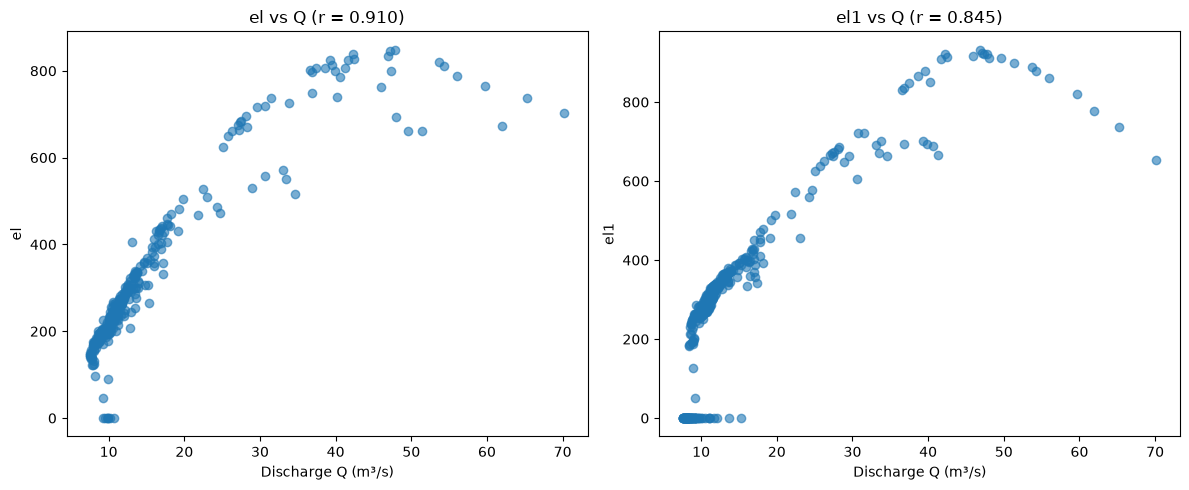

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# el
axes[0].scatter(df["Q_m³/s"], df["el"], alpha=0.6)
axes[0].set_xlabel("Discharge Q (m³/s)")
axes[0].set_ylabel("el")
axes[0].set_title(f"el vs Q (r = {corr_el:.3f})")

# el1
axes[1].scatter(df["Q_m³/s"], df["el1"], alpha=0.6)
axes[1].set_xlabel("Discharge Q (m³/s)")
axes[1].set_ylabel("el1")
axes[1].set_title(f"el1 vs Q (r = {corr_el1:.3f})")

plt.tight_layout()
plt.show()

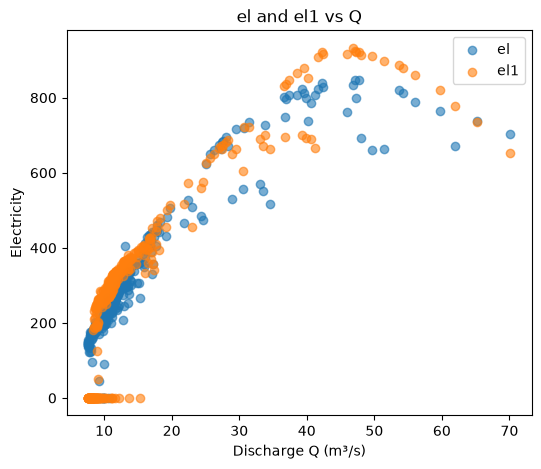

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(df["Q_m³/s"], df["el"], alpha=0.6, label="el")
plt.scatter(df["Q_m³/s"], df["el1"], alpha=0.6, label="el1")

plt.xlabel("Discharge Q (m³/s)")
plt.ylabel("Electricity")
plt.title("el and el1 vs Q")
plt.legend()

plt.show()

In [ ]:
# Load discharge data
p = pd.read_csv("pdl-main/Q_Rothenstein_1D.csv")

p["phenomenonTime"] = pd.to_datetime(p["phenomenonTime"])
p = p.set_index("phenomenonTime")

# Keep only discharge column
p = p[["Q_m³/s"]]

p.index = p.index.tz_localize(None)

# Merge
pf = power_daily.join(p, how="inner")

print(pf.head())

                    el         el1     Q_m³/s
Datum_von                                    
2025-01-01  806.791667  848.258333  37.421875
2025-01-02  806.041667  865.852083  38.607292
2025-01-03  812.375000  879.270833  39.581250
2025-01-04  801.270833  830.608333  36.557292
2025-01-05  797.541667  835.504167  36.864583


In [ ]:
corr_el  = pf["el"].corr(pf["Q_m³/s"])
corr_el1 = pf["el1"].corr(pf["Q_m³/s"])

print("Correlation (el vs Q):", corr_el)
print("Correlation (el1 vs Q):", corr_el1)

Correlation (el vs Q): 0.9104208916567624
Correlation (el1 vs Q): 0.84493662376699
